In [1]:
!nvidia-smi
!pip install -q open_clip_torch ipywidgets

from google.colab import drive
drive.mount("/content/drive")

Sat Sep 19 14:18:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from pathlib import Path
import copy
import json
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from IPython.display import display
import ipywidgets as widgets

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import STL10
from torchvision.transforms import functional as TF
from torchvision.models import (
    resnet50,
    ResNet50_Weights,
    vit_b_16,
    ViT_B_16_Weights,
)

import open_clip

from tqdm.auto import tqdm

In [3]:
PROJECT_ROOT = Path("/content/drive/MyDrive/ATML/PA1")
TASK1_ROOT = PROJECT_ROOT / "task1"

DATA_ROOT = PROJECT_ROOT / "datasets"
SPLITS_DIR = TASK1_ROOT / "splits"
FEATURES_DIR = TASK1_ROOT / "cached_features"
CHECKPOINTS_DIR = TASK1_ROOT / "checkpoints"
RESULTS_DIR = TASK1_ROOT / "results"
FIGURES_DIR = TASK1_ROOT / "figures"

CUE_ROOT = TASK1_ROOT / "data" / "cue_conflicts"
CANDIDATE_DIR = CUE_ROOT / "candidates"
ADAIN_MODEL_DIR = TASK1_ROOT / "external_models" / "adain"

for directory in [
    CUE_ROOT,
    CANDIDATE_DIR,
    ADAIN_MODEL_DIR,
    FEATURES_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

SEED = 6304
IMAGE_SIZE = 224
NUM_CLASSES = 10

STYLE_STRENGTH = 0.8
CANDIDATES_PER_DIRECTION = 30
FINAL_PER_DIRECTION = 20

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CLASS_NAMES = [
    "airplane",
    "bird",
    "car",
    "cat",
    "deer",
    "dog",
    "horse",
    "monkey",
    "ship",
    "truck",
]

print("Device:", DEVICE)

Device: cuda


In [4]:
def set_seed(seed=6304):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

In [5]:
test_dataset_raw = STL10(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=None,
)

TEST_SUBSET_PATH = (
    SPLITS_DIR / "stl10_test_subset_500_seed6304.json"
)

with open(TEST_SUBSET_PATH, "r") as file:
    saved_test_subset = json.load(file)

test_indices = np.array(
    saved_test_subset["test_indices"]
)

print("Test images available:", len(test_indices))

Test images available: 500


In [6]:
#AdaIN setup

ADAIN_CODE_DIR = Path("/content/pytorch-AdaIN")

if not ADAIN_CODE_DIR.exists():
    !git clone -q https://github.com/naoto0804/pytorch-AdaIN.git /content/pytorch-AdaIN

print("AdaIN code location:", ADAIN_CODE_DIR)

AdaIN code location: /content/pytorch-AdaIN


In [7]:
DECODER_PATH = ADAIN_MODEL_DIR / "decoder.pth"
VGG_PATH = ADAIN_MODEL_DIR / "vgg_normalised.pth"

if not DECODER_PATH.exists():
    !wget -q --show-progress \
        -O "{DECODER_PATH}" \
        "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/decoder.pth"

if not VGG_PATH.exists():
    !wget -q --show-progress \
        -O "{VGG_PATH}" \
        "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/vgg_normalised.pth"

print("Decoder exists:", DECODER_PATH.exists())
print("VGG exists:", VGG_PATH.exists())
print("Decoder size:", DECODER_PATH.stat().st_size)
print("VGG size:", VGG_PATH.stat().st_size)

/content/drive/MyDr 100%[===================>]  13.37M  28.9MB/s    in 0.5s    
/content/drive/MyDr 100%[===================>]  76.39M  26.7MB/s    in 2.9s    
Decoder exists: True
VGG exists: True
Decoder size: 14023458
VGG size: 80102481


In [8]:
if str(ADAIN_CODE_DIR) not in sys.path:
    sys.path.insert(0, str(ADAIN_CODE_DIR))

from net import decoder, vgg
from function import adaptive_instance_normalization

adain_decoder = copy.deepcopy(decoder)
adain_vgg = copy.deepcopy(vgg)

adain_decoder.load_state_dict(
    torch.load(
        DECODER_PATH,
        map_location="cpu",
        weights_only=True,
    )
)

adain_vgg.load_state_dict(
    torch.load(
        VGG_PATH,
        map_location="cpu",
        weights_only=True,
    )
)

# AdaIN uses VGG layers up to relu4_1.
adain_vgg = nn.Sequential(
    *list(adain_vgg.children())[:31]
)

adain_decoder = adain_decoder.to(DEVICE).eval()
adain_vgg = adain_vgg.to(DEVICE).eval()

for parameter in adain_decoder.parameters():
    parameter.requires_grad = False

for parameter in adain_vgg.parameters():
    parameter.requires_grad = False

print("AdaIN models loaded.")

AdaIN models loaded.


In [9]:
common_resize = transforms.Resize(
    (IMAGE_SIZE, IMAGE_SIZE),
    interpolation=transforms.InterpolationMode.BICUBIC,
    antialias=True,
)

adain_input_transform = transforms.Compose([
    common_resize,
    transforms.ToTensor(),
])


@torch.inference_mode()
def stylize_image(
    content_image,
    style_image,
    alpha=STYLE_STRENGTH,
):
    content_tensor = (
        adain_input_transform(content_image)
        .unsqueeze(0)
        .to(DEVICE)
    )

    style_tensor = (
        adain_input_transform(style_image)
        .unsqueeze(0)
        .to(DEVICE)
    )

    content_features = adain_vgg(content_tensor)
    style_features = adain_vgg(style_tensor)

    transferred_features = (
        adaptive_instance_normalization(
            content_features,
            style_features,
        )
    )

    blended_features = (
        alpha * transferred_features
        + (1 - alpha) * content_features
    )

    output = adain_decoder(blended_features)

    output = (
        output.squeeze(0)
        .clamp(0, 1)
        .cpu()
    )

    return TF.to_pil_image(output)

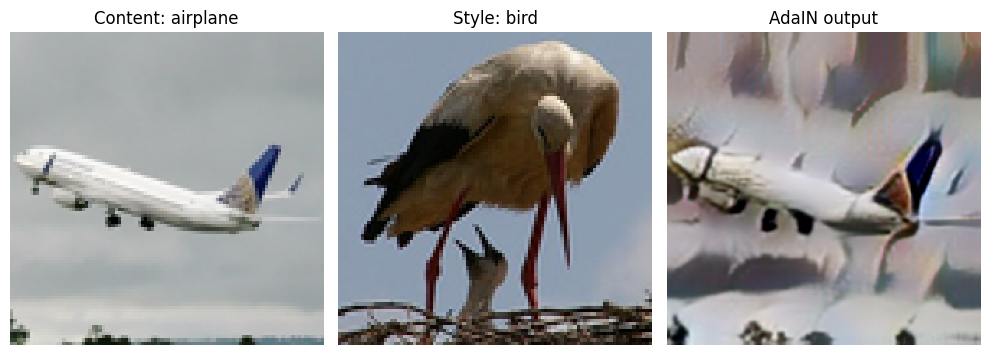

In [10]:
labels_array = np.array(
    test_dataset_raw.labels
)

airplane_indices = [
    index for index in test_indices
    if labels_array[index] == 0
]

bird_indices = [
    index for index in test_indices
    if labels_array[index] == 1
]

content_image, _ = test_dataset_raw[
    airplane_indices[0]
]

style_image, _ = test_dataset_raw[
    bird_indices[0]
]

stylized_image = stylize_image(
    content_image.convert("RGB"),
    style_image.convert("RGB"),
)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].imshow(content_image)
axes[0].set_title("Content: airplane")

axes[1].imshow(style_image)
axes[1].set_title("Style: bird")

axes[2].imshow(stylized_image)
axes[2].set_title("AdaIN output")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

In [11]:
CLASS_PAIRS = [
    ("airplane", "bird"),
    ("car", "cat"),
    ("deer", "ship"),
    ("dog", "truck"),
    ("horse", "monkey"),
]

CLASS_TO_ID = {
    class_name: class_id
    for class_id, class_name
    in enumerate(CLASS_NAMES)
}

for pair in CLASS_PAIRS:
    print(pair)

('airplane', 'bird')
('car', 'cat')
('deer', 'ship')
('dog', 'truck')
('horse', 'monkey')


In [13]:
CANDIDATE_METADATA_PATH = (
    CUE_ROOT / "candidate_metadata.csv"
)

if CANDIDATE_METADATA_PATH.exists():
    candidate_metadata = pd.read_csv(
        CANDIDATE_METADATA_PATH
    )

    print("Loaded existing candidate metadata.")

else:
    rng = np.random.default_rng(SEED)
    metadata_rows = []

    class_to_indices = {}

    for class_id in range(NUM_CLASSES):
        class_to_indices[class_id] = np.array([
            index
            for index in test_indices
            if labels_array[index] == class_id
        ])

    for pair_id, (
        first_class_name,
        second_class_name,
    ) in enumerate(CLASS_PAIRS):

        first_class = CLASS_TO_ID[
            first_class_name
        ]

        second_class = CLASS_TO_ID[
            second_class_name
        ]

        directions = [
            (first_class, second_class),
            (second_class, first_class),
        ]

        for content_class, style_class in directions:
            content_choices = rng.choice(
                class_to_indices[content_class],
                size=CANDIDATES_PER_DIRECTION,
                replace=False,
            )

            style_choices = rng.choice(
                class_to_indices[style_class],
                size=CANDIDATES_PER_DIRECTION,
                replace=False,
            )

            rng.shuffle(style_choices)

            direction_name = (
                f"{CLASS_NAMES[content_class]}"
                f"_to_{CLASS_NAMES[style_class]}"
            )

            for example_number, (
                content_index,
                style_index,
            ) in enumerate(
                zip(
                    content_choices,
                    style_choices,
                )
            ):
                candidate_id = (
                    f"pair{pair_id}_"
                    f"{direction_name}_"
                    f"{example_number:02d}"
                )

                metadata_rows.append({
                    "candidate_id": candidate_id,
                    "pair_id": pair_id,
                    "direction": direction_name,
                    "content_index": int(
                        content_index
                    ),
                    "style_index": int(
                        style_index
                    ),
                    "content_label": int(
                        content_class
                    ),
                    "style_label": int(
                        style_class
                    ),
                    "content_class": (
                        CLASS_NAMES[content_class]
                    ),
                    "style_class": (
                        CLASS_NAMES[style_class]
                    ),
                    "style_strength": (
                        STYLE_STRENGTH
                    ),
                    "file_name": (
                        f"{candidate_id}.png"
                    ),
                })

    candidate_metadata = pd.DataFrame(
        metadata_rows
    )

    candidate_metadata.to_csv(
        CANDIDATE_METADATA_PATH,
        index=False,
    )

    print("Created candidate metadata.")

print("Number of candidates:", len(candidate_metadata))

display(
    candidate_metadata.groupby(
        ["pair_id", "direction"]
    ).size()
)

Created candidate metadata.
Number of candidates: 300


pair_id  direction       
0        airplane_to_bird    30
         bird_to_airplane    30
1        car_to_cat          30
         cat_to_car          30
2        deer_to_ship        30
         ship_to_deer        30
3        dog_to_truck        30
         truck_to_dog        30
4        horse_to_monkey     30
         monkey_to_horse     30
dtype: int64

In [14]:
for row in tqdm(
    candidate_metadata.itertuples(index=False),
    total=len(candidate_metadata),
    desc="Generating cue conflicts",
):
    output_path = (
        CANDIDATE_DIR / row.file_name
    )

    if output_path.exists():
        continue

    content_image, _ = test_dataset_raw[
        int(row.content_index)
    ]

    style_image, _ = test_dataset_raw[
        int(row.style_index)
    ]

    stylized_image = stylize_image(
        content_image.convert("RGB"),
        style_image.convert("RGB"),
        alpha=float(row.style_strength),
    )

    stylized_image.save(output_path)

print("Candidate generation complete.")

Generating cue conflicts:   0%|          | 0/300 [00:00<?, ?it/s]

Candidate generation complete.


In [15]:
missing_files = []

for row in candidate_metadata.itertuples(
    index=False
):
    image_path = CANDIDATE_DIR / row.file_name

    if not image_path.exists():
        missing_files.append(row.candidate_id)
        continue

    with Image.open(image_path) as image:
        assert image.size == (
            IMAGE_SIZE,
            IMAGE_SIZE,
        )

assert len(missing_files) == 0

print("All 300 candidate images are present.")

All 300 candidate images are present.


Reject a stylization if the content object is no longer visually recognizable, the image contains severe decoder artifacts, the output is blank or corrupted, or the intended style produces no visible texture or appearance change. Model predictions will not be used to accept or reject images.

In [16]:
DECISIONS_PATH = (
    CUE_ROOT / "visual_review_decisions.json"
)

if DECISIONS_PATH.exists():
    with open(DECISIONS_PATH, "r") as file:
        review_decisions = json.load(file)
else:
    review_decisions = {}

review_output = widgets.Output()

accept_button = widgets.Button(
    description="Accept",
    button_style="success",
)

reject_button = widgets.Button(
    description="Reject",
    button_style="danger",
)

previous_button = widgets.Button(
    description="Previous",
)

progress_label = widgets.Label()

current_position = 0


def save_review_decisions():
    with open(DECISIONS_PATH, "w") as file:
        json.dump(
            review_decisions,
            file,
            indent=2,
        )


def find_next_unreviewed(start_position):
    for position in range(
        start_position,
        len(candidate_metadata),
    ):
        candidate_id = candidate_metadata.iloc[
            position
        ]["candidate_id"]

        if candidate_id not in review_decisions:
            return position

    return len(candidate_metadata)


def render_candidate():
    review_output.clear_output(wait=True)

    if current_position >= len(
        candidate_metadata
    ):
        with review_output:
            print("Visual review complete.")

        progress_label.value = (
            f"Reviewed "
            f"{len(review_decisions)}/"
            f"{len(candidate_metadata)}"
        )
        return

    row = candidate_metadata.iloc[
        current_position
    ]

    content_image, _ = test_dataset_raw[
        int(row["content_index"])
    ]

    style_image, _ = test_dataset_raw[
        int(row["style_index"])
    ]

    stylized_image = Image.open(
        CANDIDATE_DIR / row["file_name"]
    ).convert("RGB")

    with review_output:
        fig, axes = plt.subplots(
            1,
            3,
            figsize=(11, 4),
        )

        axes[0].imshow(content_image)
        axes[0].set_title(
            f"Content/shape:\n"
            f"{row['content_class']}"
        )

        axes[1].imshow(style_image)
        axes[1].set_title(
            f"Style/texture:\n"
            f"{row['style_class']}"
        )

        axes[2].imshow(stylized_image)

        existing_decision = (
            review_decisions.get(
                row["candidate_id"],
                "not reviewed",
            )
        )

        axes[2].set_title(
            f"Candidate: {row['candidate_id']}\n"
            f"Decision: {existing_decision}"
        )

        for axis in axes:
            axis.axis("off")

        plt.tight_layout()
        plt.show()

    progress_label.value = (
        f"Image {current_position + 1}/"
        f"{len(candidate_metadata)} | "
        f"Reviewed: {len(review_decisions)}"
    )


def accept_candidate(button):
    global current_position

    candidate_id = candidate_metadata.iloc[
        current_position
    ]["candidate_id"]

    review_decisions[candidate_id] = "accepted"
    save_review_decisions()

    current_position = find_next_unreviewed(
        current_position + 1
    )

    render_candidate()


def reject_candidate(button):
    global current_position

    candidate_id = candidate_metadata.iloc[
        current_position
    ]["candidate_id"]

    review_decisions[candidate_id] = "rejected"
    save_review_decisions()

    current_position = find_next_unreviewed(
        current_position + 1
    )

    render_candidate()


def show_previous(button):
    global current_position

    current_position = max(
        0,
        current_position - 1,
    )

    render_candidate()


accept_button.on_click(accept_candidate)
reject_button.on_click(reject_candidate)
previous_button.on_click(show_previous)

current_position = find_next_unreviewed(0)

display(progress_label)
display(
    widgets.HBox([
        previous_button,
        accept_button,
        reject_button,
    ])
)
display(review_output)

render_candidate()

Label(value='')

Output()

In [17]:
assert len(review_decisions) == len(
    candidate_metadata
), (
    f"Only {len(review_decisions)} of "
    f"{len(candidate_metadata)} candidates "
    "have been reviewed."
)

candidate_metadata["decision"] = (
    candidate_metadata["candidate_id"]
    .map(review_decisions)
)

review_summary = (
    candidate_metadata
    .groupby(
        [
            "pair_id",
            "direction",
            "decision",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

display(review_summary)

print(
    "\nTotal accepted:",
    (candidate_metadata["decision"]
     == "accepted").sum(),
)

print(
    "Total rejected:",
    (candidate_metadata["decision"]
     == "rejected").sum(),
)

decision,pair_id,direction,accepted,rejected
0,0,airplane_to_bird,20,10
1,0,bird_to_airplane,22,8
2,1,car_to_cat,29,1
3,1,cat_to_car,28,2
4,2,deer_to_ship,27,3
5,2,ship_to_deer,26,4
6,3,dog_to_truck,29,1
7,3,truck_to_dog,28,2
8,4,horse_to_monkey,29,1
9,4,monkey_to_horse,28,2



Total accepted: 266
Total rejected: 34


In [18]:
accepted_metadata = candidate_metadata[
    candidate_metadata["decision"]
    == "accepted"
].copy()

group_counts = (
    accepted_metadata
    .groupby(
        ["pair_id", "direction"]
    )
    .size()
)

print(group_counts)

assert group_counts.min() >= FINAL_PER_DIRECTION, (
    "At least one direction has fewer than "
    f"{FINAL_PER_DIRECTION} valid images. "
    "Additional candidates must be generated "
    "for that direction."
)

selected_groups = []

for _, group in accepted_metadata.groupby(
    ["pair_id", "direction"],
    sort=True,
):
    selected_group = group.sample(
        n=FINAL_PER_DIRECTION,
        random_state=SEED,
    )

    selected_groups.append(selected_group)

selected_conflicts = (
    pd.concat(
        selected_groups,
        ignore_index=True,
    )
    .sort_values("candidate_id")
    .reset_index(drop=True)
)

SELECTED_METADATA_PATH = (
    CUE_ROOT / "selected_conflicts_200.csv"
)

selected_conflicts.to_csv(
    SELECTED_METADATA_PATH,
    index=False,
)

print("Selected conflicts:", len(selected_conflicts))

display(
    selected_conflicts.groupby(
        ["pair_id", "direction"]
    ).size()
)

pair_id  direction       
0        airplane_to_bird    20
         bird_to_airplane    22
1        car_to_cat          29
         cat_to_car          28
2        deer_to_ship        27
         ship_to_deer        26
3        dog_to_truck        29
         truck_to_dog        28
4        horse_to_monkey     29
         monkey_to_horse     28
dtype: int64
Selected conflicts: 200


pair_id  direction       
0        airplane_to_bird    20
         bird_to_airplane    20
1        car_to_cat          20
         cat_to_car          20
2        deer_to_ship        20
         ship_to_deer        20
3        dog_to_truck        20
         truck_to_dog        20
4        horse_to_monkey     20
         monkey_to_horse     20
dtype: int64

In [19]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

CLIP_MEAN = (
    0.48145466,
    0.45782750,
    0.40821073,
)

CLIP_STD = (
    0.26862954,
    0.26130258,
    0.27577711,
)


def get_normalization(model_name):
    if model_name in ["resnet50", "vit_b_16"]:
        return transforms.Normalize(
            IMAGENET_MEAN,
            IMAGENET_STD,
        )

    if model_name == "clip_vit_b_32":
        return transforms.Normalize(
            CLIP_MEAN,
            CLIP_STD,
        )

    raise ValueError(model_name)


class CueConflictDataset(Dataset):
    def __init__(self, metadata, model_name):
        self.metadata = metadata.reset_index(
            drop=True
        )

        self.normalization = get_normalization(
            model_name
        )

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):
        row = self.metadata.iloc[index]

        image = Image.open(
            CANDIDATE_DIR / row["file_name"]
        ).convert("RGB")

        image = TF.to_tensor(image)
        image = self.normalization(image)

        return (
            image,
            int(row["content_label"]),
            int(row["style_label"]),
            index,
        )

In [20]:
class FrozenBackbone(nn.Module):
    def __init__(self, model_name):
        super().__init__()

        self.model_name = model_name

        if model_name == "resnet50":
            model = resnet50(
                weights=ResNet50_Weights.IMAGENET1K_V2
            )

            model.fc = nn.Identity()
            self.feature_dim = 2048

        elif model_name == "vit_b_16":
            model = vit_b_16(
                weights=ViT_B_16_Weights.IMAGENET1K_V1
            )

            model.heads = nn.Identity()
            self.feature_dim = 768

        elif model_name == "clip_vit_b_32":
            model, _, _ = (
                open_clip.create_model_and_transforms(
                    model_name="ViT-B-32-quickgelu",
                    pretrained="openai",
                )
            )

            self.feature_dim = (
                model.visual.output_dim
            )

        else:
            raise ValueError(model_name)

        self.model = model

        for parameter in self.model.parameters():
            parameter.requires_grad = False

        self.model.eval()

    def forward(self, images):
        if self.model_name == "clip_vit_b_32":
            features = self.model.encode_image(
                images
            )

            return F.normalize(
                features,
                dim=1,
            )

        return self.model(images)


def load_linear_head(model_name):
    checkpoint = torch.load(
        CHECKPOINTS_DIR
        / f"{model_name}_linear_head.pt",
        map_location=DEVICE,
        weights_only=False,
    )

    head = nn.Linear(
        checkpoint["feature_dim"],
        checkpoint["number_of_classes"],
    ).to(DEVICE)

    head.load_state_dict(
        checkpoint["state_dict"]
    )

    head.eval()

    return head

In [21]:
@torch.inference_mode()
def extract_conflict_features(
    backbone,
    loader,
    model_name,
):
    all_features = []
    all_content_labels = []
    all_style_labels = []
    all_positions = []

    for (
        images,
        content_labels,
        style_labels,
        positions,
    ) in tqdm(
        loader,
        desc=f"{model_name}: cue conflicts",
    ):
        images = images.to(DEVICE)

        features = backbone(images)

        all_features.append(
            features.float().cpu()
        )

        all_content_labels.append(
            content_labels
        )

        all_style_labels.append(
            style_labels
        )

        all_positions.append(
            positions
        )

    positions = torch.cat(
        all_positions
    )

    return {
        "features": torch.cat(
            all_features
        ),
        "content_labels": torch.cat(
            all_content_labels
        ),
        "style_labels": torch.cat(
            all_style_labels
        ),
        "positions": positions,
        "candidate_ids": (
            selected_conflicts.iloc[
                positions.numpy()
            ]["candidate_id"].tolist()
        ),
    }

In [22]:
MODEL_NAMES = [
    "resnet50",
    "vit_b_16",
    "clip_vit_b_32",
]

summary_rows = []
prediction_rows = []

for model_name in MODEL_NAMES:
    print("\nProcessing:", model_name)

    backbone = FrozenBackbone(
        model_name
    ).to(DEVICE)

    feature_path = (
        FEATURES_DIR
        / f"{model_name}_cue_conflicts_200.pt"
    )

    if feature_path.exists():
        conflict_data = torch.load(
            feature_path,
            map_location="cpu",
            weights_only=False,
        )

        print("Loaded cached features.")

    else:
        dataset = CueConflictDataset(
            selected_conflicts,
            model_name,
        )

        loader = DataLoader(
            dataset,
            batch_size=64,
            shuffle=False,
            num_workers=0,
            pin_memory=False,
        )

        conflict_data = (
            extract_conflict_features(
                backbone,
                loader,
                model_name,
            )
        )

        torch.save(
            conflict_data,
            feature_path,
        )

    linear_head = load_linear_head(
        model_name
    )

    evaluation_systems = {
        "linear_head": linear_head(
            conflict_data["features"].to(
                DEVICE
            )
        )
    }

    if model_name == "clip_vit_b_32":
        tokenizer = open_clip.get_tokenizer(
            "ViT-B-32-quickgelu"
        )

        prompts = [
            f"a photo of a {class_name}."
            for class_name in CLASS_NAMES
        ]

        tokens = tokenizer(prompts).to(
            DEVICE
        )

        with torch.inference_mode():
            text_features = (
                backbone.model.encode_text(
                    tokens
                )
            )

            text_features = F.normalize(
                text_features,
                dim=1,
            )

            zero_shot_logits = (
                backbone.model.logit_scale.exp()
                * conflict_data["features"].to(
                    DEVICE
                )
                @ text_features.T
            )

        evaluation_systems[
            "zero_shot"
        ] = zero_shot_logits

    content_labels = (
        conflict_data["content_labels"]
        .numpy()
    )

    style_labels = (
        conflict_data["style_labels"]
        .numpy()
    )

    for evaluation_type, logits in (
        evaluation_systems.items()
    ):
        predictions = (
            logits.argmax(dim=1)
            .cpu()
            .numpy()
        )

        shape_mask = (
            predictions == content_labels
        )

        texture_mask = (
            predictions == style_labels
        )

        other_mask = ~(
            shape_mask | texture_mask
        )

        number_shape = int(
            shape_mask.sum()
        )

        number_texture = int(
            texture_mask.sum()
        )

        number_other = int(
            other_mask.sum()
        )

        total = len(predictions)

        shape_texture_total = (
            number_shape + number_texture
        )

        if shape_texture_total > 0:
            shape_bias = (
                100
                * number_shape
                / shape_texture_total
            )
        else:
            shape_bias = np.nan

        coverage = (
            100
            * shape_texture_total
            / total
        )

        summary_rows.append({
            "model": model_name,
            "evaluation": evaluation_type,
            "n_shape": number_shape,
            "n_texture": number_texture,
            "n_other": number_other,
            "n_total": total,
            "shape_bias_percent": shape_bias,
            "coverage_percent": coverage,
        })

        for position, prediction in enumerate(
            predictions
        ):
            if shape_mask[position]:
                category = "shape"
            elif texture_mask[position]:
                category = "texture"
            else:
                category = "other"

            metadata_row = (
                selected_conflicts.iloc[
                    position
                ]
            )

            prediction_rows.append({
                "candidate_id": (
                    metadata_row[
                        "candidate_id"
                    ]
                ),
                "model": model_name,
                "evaluation": evaluation_type,
                "content_class": (
                    metadata_row[
                        "content_class"
                    ]
                ),
                "style_class": (
                    metadata_row[
                        "style_class"
                    ]
                ),
                "predicted_class": (
                    CLASS_NAMES[prediction]
                ),
                "decision_category": category,
            })

    del backbone
    del linear_head

    torch.cuda.empty_cache()


Processing: resnet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 112MB/s]


resnet50: cue conflicts:   0%|          | 0/4 [00:00<?, ?it/s]


Processing: vit_b_16
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 180MB/s]


vit_b_16: cue conflicts:   0%|          | 0/4 [00:00<?, ?it/s]


Processing: clip_vit_b_32


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

clip_vit_b_32: cue conflicts:   0%|          | 0/4 [00:00<?, ?it/s]

In [23]:
cue_summary_df = pd.DataFrame(
    summary_rows
)

cue_predictions_df = pd.DataFrame(
    prediction_rows
)

cue_summary_df.to_csv(
    RESULTS_DIR
    / "cue_conflict_summary.csv",
    index=False,
)

cue_predictions_df.to_csv(
    RESULTS_DIR
    / "cue_conflict_predictions.csv",
    index=False,
)

display(
    cue_summary_df.round(2)
)

,model,evaluation,n_shape,n_texture,n_other,n_total,shape_bias_percent,coverage_percent
0,resnet50,linear_head,85,47,68,200,64.39,66.0
1,vit_b_16,linear_head,134,13,53,200,91.16,73.5
2,clip_vit_b_32,linear_head,150,8,42,200,94.94,79.0
3,clip_vit_b_32,zero_shot,157,16,27,200,90.75,86.5


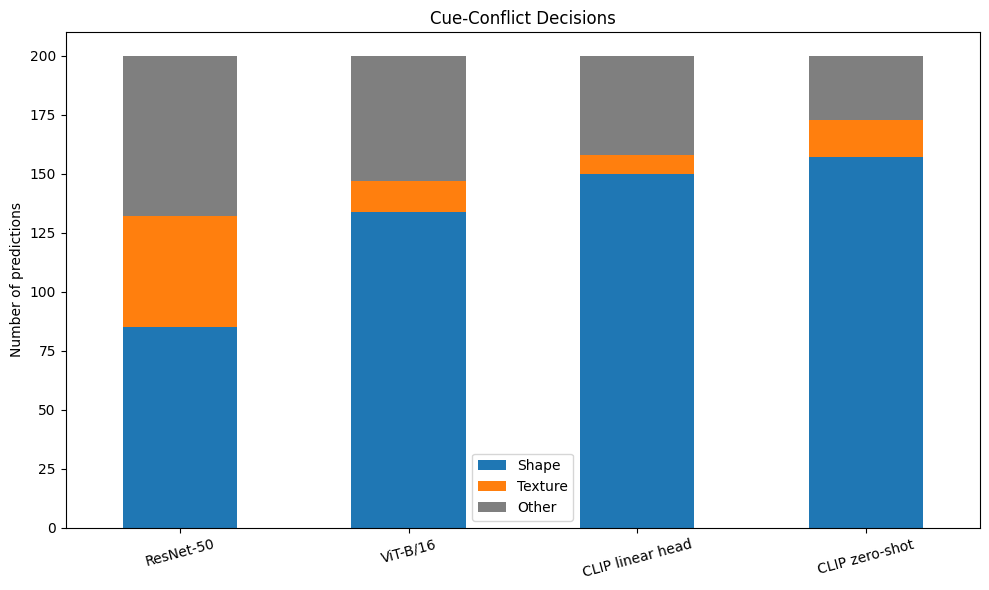

In [24]:
def system_name(row):
    if (
        row["model"] == "clip_vit_b_32"
        and row["evaluation"] == "zero_shot"
    ):
        return "CLIP zero-shot"

    if row["model"] == "clip_vit_b_32":
        return "CLIP linear head"

    if row["model"] == "vit_b_16":
        return "ViT-B/16"

    return "ResNet-50"


cue_summary_df["system"] = (
    cue_summary_df.apply(
        system_name,
        axis=1,
    )
)

plot_data = (
    cue_summary_df.set_index("system")[
        [
            "n_shape",
            "n_texture",
            "n_other",
        ]
    ]
)

plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=[
        "tab:blue",
        "tab:orange",
        "tab:gray",
    ],
)

plt.ylabel("Number of predictions")
plt.xlabel("")
plt.title("Cue-Conflict Decisions")
plt.legend(
    ["Shape", "Texture", "Other"]
)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "cue_conflict_decision_counts.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [25]:
assert len(cue_summary_df) == 4

assert np.all(
    cue_summary_df[
        [
            "n_shape",
            "n_texture",
            "n_other",
        ]
    ].sum(axis=1) == 200
)

assert cue_summary_df[
    "coverage_percent"
].between(0, 100).all()

assert cue_summary_df[
    "shape_bias_percent"
].dropna().between(0, 100).all()

print("All cue-conflict checks passed.")

All cue-conflict checks passed.
